In [5]:
import math

capital_letters = 26
small_letters = 26
digits = 10
special_characters = 33
all_characters = 95
l = 13
passphrase = (math.comb(l,4)) * capital_letters * small_letters * digits * special_characters * all_characters ** (l-4)

mnemonic_BIP39 = 2048
unique_biometric = 5*2

possible_combinations = passphrase * mnemonic_BIP39 * unique_biometric
print(possible_combinations)
print(2**128)

2058775908347424552000000000000
340282366920938463463374607431768211456


In [1]:
!pip install deepface
!pip install hkdf
!pip install argon2-cffi
!pip install pycryptodome


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.3/128.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for hkdf: filename=hkdf-0.0.3-py3-none-any.whl size=3716 sha256=a2712309a8617b0b14dc0bd6cd215b36fdcc9457f834bbf3244e7913be1d1a21
  Stored in directory: /root/.cache/pip/wheels/28/e4/02/e221c30457e055cadbf40240b9b7810f219faecf8cdb7ec6d6
Successfully built hkdf
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 28.3 MB/s eta 0:00:00


# Test vector

In [25]:
import hashlib
from argon2 import PasswordHasher
from hkdf import Hkdf

def derive_seed_from_biometrics(passphrase: str, biometric_string: str, info: bytes = b'wallet-v1') -> bytes:
    biometric_hash = hashlib.sha256(biometric_string.encode('utf-8')).digest()
    pre_salt = passphrase.encode('utf-8') + biometric_hash + info
    salt = hashlib.sha256(pre_salt).digest()[:16]
    ph = PasswordHasher()
    passphrase_hash = ph.hash(passphrase.encode('utf-8'), salt=salt)
    hkdf = Hkdf(salt, passphrase_hash.encode('utf-8'))
    seed = hkdf.expand(biometric_hash, 16)  # 16 bytes = 128 bits
    return seed

def get_mnemonic_from_seed(seed_bytes: bytes, wordlist_path: str = 'english.txt') -> str:
    checksum = hashlib.sha256(seed_bytes).digest()
    first_byte = checksum[0]
    checksum_bits = format(first_byte >> 4, '04b')
    seed_bits = ''.join(format(byte, '08b') for byte in seed_bytes)
    combined_bits = seed_bits + checksum_bits
    last_11_bits = combined_bits[-11:]
    word_index = int(last_11_bits, 2)
    with open(wordlist_path, 'r') as f:
        wordlist = f.read().splitlines()
    return wordlist[word_index]

# --- Test Vector Execution ---
# Representative data from the biometric processing functions
passphrase_input = "Sup3rSecur3Key!!"
biometric_input = 'happyWoman41 32 129 160 76 0 136 88 16 192 144 196 129 133 80 132 88 65 2 221 65 67 2 128 8 80 139 136 6 1 96 240 169 32 225 36 108 96 137 8 74 192 16 4 21 32 80 2 64 68 0 5 129 66 194 128 0 128 170 40 4 44 80 224 32 192 4 0 88 3 64 89 130 1 129 88 83 1 160 18 1 128 70 8 26 3 8 7 24 6 53 84 48 130 128 32 52 224 64 32 0 2 65 28 18 33 145 18 19 129 72 0 25 140 4 8 72 69 8 18 200 132 48 84 32 136 0 32 117 4 64 2 136 160 64 3 130 16 137 12 3 192 64 19 1 194 104 26 26 65 146 32 184 128 4 88 160 131 128 0 20 32 129 52 128 4 0 80 18 128 129 88 55 224 64 8 19 224 12 80 24 67 8 0 217 130 33 48 128 33 2 0 20 32 128 50 8 36 2 0 144 138 128 64 48 224 65 72 17 98 72 0 2 65 136 42 9 132 32 56 160 65 64 0 8 32 4 84 16 130 64 52 32 160 132 16 56 3 128 19 72 230 68 136 40 74 0 108 42 11 118 32 2 128 130 8 80 64 140 4 8 0 0 8 0 128 192 10 64 224 1 10 0 64 32 64 2 66 18 1 144 3 0 56 0 49 0 0 64 0 128 4 0 32 0 8 18 0 128 8 96 96 1 8 16 73 40 0 0 67 146 1 19 2 97 56 0 121 0 2 64 0 128 20 0 36 0 8 16 2 128 0 97 240 72 0 16 64 72 128 0 65 138 8 1 64 97 56 0 65 0 2 0 0 1 22 8 36 0 0 144 11 128 64 96 240 72 0 17 64 72 32 32 65 136 32 1 128 96 58 128 64 0 2 4 4 0 18 8 4 0 132 130 10 0 64 112 240 73 11 129 72 104 2 0 65 138 34 0 132 116 2 128 80 0 11 120 4 128 180 16 0 8 22 0 1 4 18 32 35 0 18 64 194 4 136 56 8 192 162 178 5 146 0 2 128 130 0 80 6 0 36 16 0 64 22 1 129 128 16 33 35 64 66 64 230 4 128 40 8 192 10 178 64 132 0 34 192 128 0 16 22 0 68 0 8 32 16 16 2 0 229 131 0 0 0 37 0 4 0 168 12 4 2 132 128 32 128 40 128 0 16 18 0 65 32 0 0 72 88 160 0 144 2 0 12 148 2 169 128 29 160 136 1 128 0 16 8 161 140 37 32 114 0 19 0 65 64 12 0 64 72 129 130 144 2 16 24 144 2 40 128 21 160 8 3 4 0 16 8 129 172 37 32 114 32 64 4 128 164 0 8 68 55 17 7 2 18 1 32 0 96 96 6 42 0 48 9 129 131 49 228 128 16 32 8 160 4 80 0 2 4 0 5 68 35 5 8 138 16 2 160 32 66 64 130 44 0 72 9 1 2 128 132 0 16 32 64 128 0 16 4 6 0 0 3 0 34 132 66 10 0 66 32 36 0 128 0 76 32 72 1 2 8 128 10 80 0 0 64 0 64 0 184 8 178 40 176 30 128 130 67 16 184 132 196 202 32 143 19 212 3 142 2 170 179 192 69 40 232 4 9 132 81 128 36 4 8 8 35 0 106 132 2 64 16 0 16 0 1 128 0 66 32 48 128 0 12 0 0 64 2 0 0 0 0 19 160 160 82 10 144 136 192 138 17 16 146 9 140 212 34 39 64 88 80 150 77 174 160 138 72 24 248 4 1 1 148 198 65 224 16 202 32 184 152 162 81 20 8 72 193 217 14 38 66 113 220 130 71 138 64 26 8 4 168 135 213 3 224 198 64 192 82 66 0 168 220 162 17 20 26 72 225 216 14 34 64 113 220 0 66 138 224 10 10 80 168 135 149 131 192 2 64 194 82 4 32 104 196 131 17 20 18 8 233 220 10 34 72 17 200 0 66 138 224 10 8 80 168 167 213 98 128 2 68 2 0 128 0 12 3 0 2 8 192 0 12 16 128 1 2 17 1 193 132 0 0 32 4 12 128 132 64 144 32 2 4 1 0 0 32 12 3 0 0 8 64 16 0 16 0 1 1 17 129 1 132 0 0 32 0 140 128 12 64 128 0 204 65 228 0 202 32 136 152 162 81 28 24 72 193 90 30 14 64 113 216 130 71 14 64 2 8 5 136 135 212 131 224 4 64 192 18 68 32 104 20 131 17 21 18 64 233 92 10 40 64 49 136 0 66 138 224 2 10 192 40 167 213 98 128 76 1 228 0 200 0 140 152 130 81 140 24 72 193 90 22 4 192 113 200 192 70 78 64 66 9 197 140 135 246 160 0 70 65 228 48 200 0 76 152 227 81 20 2 73 65 24 14 8 64 113 136 128 66 78 128 6 74 197 140 167 177 162 128 68 64 224 176 76 0 76 16 193 17 21 2 73 105 24 10 73 64 96 137 128 66 202 128 22 74 192 8 167 145 226 128 0 128 133 16 148 0 0 9 130 17 0 80 0 40 16 130 1 64 0 65 17 76 0 0 8 128 85 64 132 32 128 0 1 128 132 144 148 0 5 1 2 19 0 18 0 96 8 134 1 64 0 0 49 96 0 160 40 2 69 0 128 0 136 32 21 4 132 16 128 16 7 3 18 19 20 18 64 96 8 44 17 66 0 8 49 96 32 32 160 2 4 0 128 72 128 36 0 137 129 16 132 0 0 136 18 17 0 80 0 168 64 128 0 64 0 64 17 108 0 0 8 0 65 68 128 33 128 0 4 0 128 16 128 0 133 160 18 3 16 18 0 96 0 140 17 66 0 0 17 96 0 0 8 2 65 0 192 33 128 32 5 0 128 16 128 16 133 2 18 3 20 16 0 96 136 36 17 66 0 8 49 96 32 34 0 6 0 0 192 73 128 36 24 20 36 69 0 26 163 48 64 160 86 32 74 48 128 38 32 68 4 168 168 176 37 8 224 75 32 2 102 96 1 7 0 1 129 16 128 0 129 160 18 16 0 80 16 168 64 8 0 64 32 64 17 104 0 0 8 2 81 68 192 33 0 32 12 8 0 16 128 48 129 2 16 2 16 16 16 96 128 12 9 66 0 0 17 64 32 2 0 6 1 0 193 64 0 32 24 20 38 69 16 18 183 48 96 162 86 32 73 48 128 38 36 84 0 160 160 176 37 10 96 239 0 0 99 96 0 2 8 20 98 68 0 18 166 48 112 34 102 32 81 58 128 32 48 84 128 160 160 144 37 10 98 239 160 128 99 160 64 2 8 20 64 68 0 18 166 48 48 2 102 160 81 55 128 0 20 84 145 160 32 144 33 14 98 175 162 128 35 160 64 0'

# Execute the full pipeline
final_seed = derive_seed_from_biometrics(passphrase_input, biometric_input)
mnemonic_word = get_mnemonic_from_seed(final_seed)

print(f"Input Passphrase: {passphrase_input}")
print(f"Final 128-bit Seed (hex): {final_seed.hex()}")
print(f"Derived Mnemonic Word: {mnemonic_word}")
# Expected output for the mnemonic word: "rug"

Input Passphrase: Sup3rSecur3Key!!
Final 128-bit Seed (hex): fd2e47122b38c6934a3cbff43a767b5e
Derived Mnemonic Word: rug


# Test

In [24]:
import os
import re
import cv2
import numpy as np
import hashlib
import shutil
from skimage.morphology import skeletonize
from Crypto.Cipher import AES
from Crypto.Util.Padding import pad
from argon2 import PasswordHasher
from hkdf import Hkdf
from deepface import DeepFace

def derive_seed_from_biometric_salt(passphrase, biometric_data, info=b'wallet-v1'):
    """
    Derives a seed for BIP-39 mnemonic using Argon2id and HKDF,
    with the salt derived from the biometric data.
    """
    # 1. Derive the salt from the biometric data.
    #    We'll use the first 16 bytes of the SHA-256 hash of the biometric data as the salt.
    biometric_hash = hashlib.sha256(biometric_data.encode('utf-8')).digest()
    print(f"\nProcessed_biometric = {biometric_data.encode('utf-8')}")
    print(f"biometric_hash = {biometric_hash.hex()}")
    pre_salt = passphrase.encode('utf-8') + biometric_hash + info
    print(f"Pre_salt ={pre_salt}")
    salt = hashlib.sha256(pre_salt).digest()[:16]
    print(f"salt = {salt.hex()}")

    # 2. Hash the passphrase with Argon2id using the biometric-derived salt
    ph = PasswordHasher()
    # Note: Argon2-cffi's hash() function will internally use the salt.
    # We pass it as an argument to ensure it's used.
    passphrase_hash = ph.hash(passphrase.encode('utf-8'), salt=salt)
    print(f"Argon2id(passphrase, salt) = {passphrase_hash}")

    # 4. Combine the hashes with HKDF
    hkdf = Hkdf(salt, passphrase_hash.encode('utf-8'))
    # The 'info' parameter provides domain separation
    seed = hkdf.expand(biometric_hash, 16)  # 16 bytes = 128 bits for BIP39
    print(f"16-Byte HDKF combined hashes = {seed.hex()}")

    return seed

# Fingerprint Processing Function
def get_descriptors(img):
    """Process the fingerprint image to extract descriptors."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)  # Apply CLAHE for contrast enhancement
    img = np.array(img, dtype=np.uint8)
    _, img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)  # Thresholding
    img[img == 255] = 1  # Normalize to binary image
    skeleton = skeletonize(img)  # Skeletonize the image
    harris_corners = cv2.cornerHarris(img, 3, 3, 0.04)  # Detect Harris corners
    harris_normalized = cv2.normalize(harris_corners, 0, 255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32FC1)
    threshold_harris = 125  # Threshold for detecting keypoints
    keypoints = [cv2.KeyPoint(y, x, 1) for x in range(harris_normalized.shape[0]) for y in range(harris_normalized.shape[1]) if harris_normalized[x][y] > threshold_harris]
    orb = cv2.ORB_create()  # Initialize ORB detector
    _, des = orb.compute(img, keypoints)  # Compute ORB descriptors
    return ' '.join(map(str, des.flatten())) if des is not None else ''  # Return descriptors as a string

# Face Processing Function
def face_analyzer(img):
    """Analyze the face image for emotion, gender, and race."""
    objs = DeepFace.analyze(img_path=img, actions=("emotion", "gender"), enforce_detection=False, detector_backend="retinaface")
    return f"{objs[0]['dominant_emotion']}{objs[0]['dominant_gender']}"

# Common Functionality for Both Signup and Login
def process_biometrics(face_path, finger_path, key):
    """Process both face and fingerprint images, then encrypt the result."""
    face_analysis_result = face_analyzer(face_path)  # Analyze the face image
    img1 = cv2.imread(finger_path, cv2.IMREAD_GRAYSCALE)  # Read the fingerprint image
    finger_analysis_result = get_descriptors(img1)  # Get fingerprint descriptors
    processed_biometric = face_analysis_result + finger_analysis_result  # Concatenate face and fingerprint data
    encrypted_data = derive_seed_from_biometric_salt(passphrase=key, biometric_data=processed_biometric)  # 128 bit
    checksum = hashlib.sha256(encrypted_data).digest()  # Compute checksum of the encrypted data
    print(f"Checksum: {checksum.hex()}")
    first_4_bits = checksum[0] >> 4  # Extract the first 4 bits of the checksum
    print(f"First 4 bits of the checksum: {first_4_bits}")
    encrypted_data_bits = ''.join(format(byte, '08b') for byte in encrypted_data)  # Convert encrypted data to binary string
    final_bit_string = encrypted_data_bits + format(first_4_bits, '04b')  # Append the first 4 bits to the binary string
    last_11_bits = final_bit_string[-11:]  # Extract the last 11 bits
    word_index = int(last_11_bits, 2)  # Convert the last 11 bits to an integer
    print(last_11_bits)
    print(word_index)
    with open('english.txt', 'r') as f:  # Load word list
        wordlist = f.read().splitlines()
    return wordlist[word_index]  # Return the mnemonic word corresponding to the index

def valid_key(key):
    """Validate that the key contains at least one uppercase, lowercase, digit, and special character."""
    return (len(key) >= 13 and
            re.search(r'[A-Z]', key) and
            re.search(r'[a-z]', key) and
            re.search(r'\d', key) and
            re.search(r'[!@#$%^&*(),.?":{}|<>]', key))

mnemonic_word = process_biometrics(
    face_path="/content/Happy_3493.png",
    finger_path="/content/8__M_Left_index_finger.BMP",
    key="Sup3rSecur3Key!!"
)

print("Mnemonic word:", mnemonic_word)


Action: gender: 100%|██████████| 2/2 [00:00<00:00,  2.77it/s]



Processed_biometric = b'happyWoman41 32 129 160 76 0 136 88 16 192 144 196 129 133 80 132 88 65 2 221 65 67 2 128 8 80 139 136 6 1 96 240 169 32 225 36 108 96 137 8 74 192 16 4 21 32 80 2 64 68 0 5 129 66 194 128 0 128 170 40 4 44 80 224 32 192 4 0 88 3 64 89 130 1 129 88 83 1 160 18 1 128 70 8 26 3 8 7 24 6 53 84 48 130 128 32 52 224 64 32 0 2 65 28 18 33 145 18 19 129 72 0 25 140 4 8 72 69 8 18 200 132 48 84 32 136 0 32 117 4 64 2 136 160 64 3 130 16 137 12 3 192 64 19 1 194 104 26 26 65 146 32 184 128 4 88 160 131 128 0 20 32 129 52 128 4 0 80 18 128 129 88 55 224 64 8 19 224 12 80 24 67 8 0 217 130 33 48 128 33 2 0 20 32 128 50 8 36 2 0 144 138 128 64 48 224 65 72 17 98 72 0 2 65 136 42 9 132 32 56 160 65 64 0 8 32 4 84 16 130 64 52 32 160 132 16 56 3 128 19 72 230 68 136 40 74 0 108 42 11 118 32 2 128 130 8 80 64 140 4 8 0 0 8 0 128 192 10 64 224 1 10 0 64 32 64 2 66 18 1 144 3 0 56 0 49 0 0 64 0 128 4 0 32 0 8 18 0 128 8 96 96 1 8 16 73 40 0 0 67 146 1 19 2 97 56 0 121 0 2 64 0 

# ideal

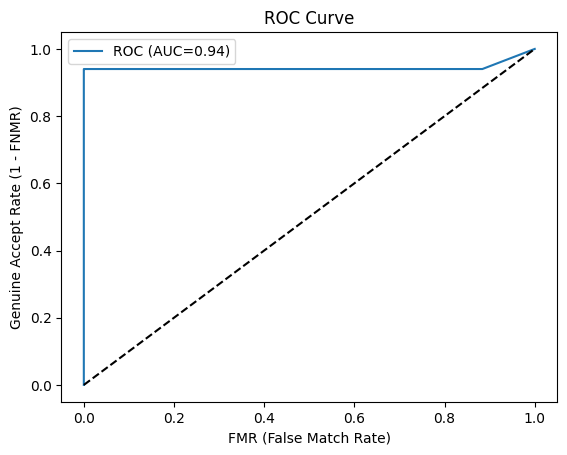

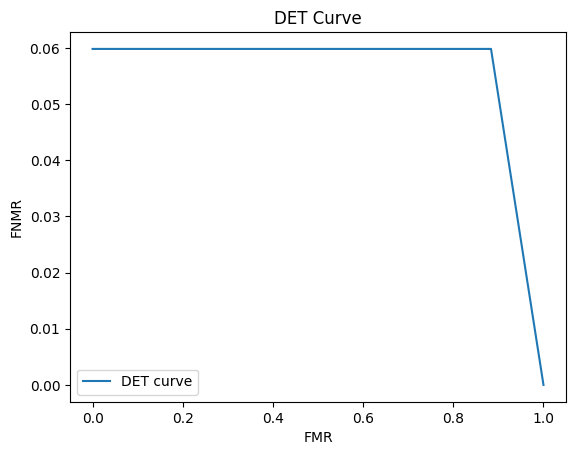

Equal Error Rate (EER): 0.0599 at threshold -71.8750
False Match Rate (FMR) at EER: 0.0599
False Non-Match Rate (FNMR) at EER: 0.0598


In [44]:
import os
import cv2
import numpy as np
from skimage.morphology import skeletonize
from itertools import combinations
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, det_curve, auc

# -----------------------------
# 1. Descriptor Extraction
# -----------------------------
def get_descriptors(img):
    # CLAHE for contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    # Threshold + skeletonization
    _, img_bin = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)
    img_bin = img_bin // 255
    skeleton = skeletonize(img_bin)
    skeleton_img = (skeleton * 255).astype(np.uint8)  # convert back to 0-255 for ORB

    # Harris corners
    harris = cv2.cornerHarris(skeleton_img, 3, 3, 0.04)
    harris_norm = cv2.normalize(harris, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_32FC1)

    keypoints = []
    for x in range(harris_norm.shape[0]):
        for y in range(harris_norm.shape[1]):
            if harris_norm[x, y] > 125:
                keypoints.append(cv2.KeyPoint(y, x, 1))

    orb = cv2.ORB_create()
    _, des = orb.compute(skeleton_img, keypoints)
    return des

# -----------------------------
# 2. Augmentation (example)
# -----------------------------
def augment(img):
    # identity (no change) for simplicity
    return img

# -----------------------------
# 3. Similarity Score
# -----------------------------
def compute_score(des1, des2):
    if des1 is None or des2 is None or len(des1)==0 or len(des2)==0:
        return -1000  # very low similarity for missing descriptors
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    if len(matches) == 0:
        return -1000
    # Option 1: use negative mean distance
    return -np.mean([m.distance for m in matches])
    # Option 2 (alternative): normalized number of matches
    # return len(matches) / max(len(des1), len(des2))

# -----------------------------
# 4. Evaluate Dataset
# -----------------------------
def evaluate(folder):
    images = [f for f in os.listdir(folder) if f.lower().endswith(".bmp")]
    descriptors = {}

    # Extract descriptors for originals + augmentations
    for img_name in images:
        img = cv2.imread(os.path.join(folder, img_name), cv2.IMREAD_GRAYSCALE)
        des_orig = get_descriptors(img)
        des_aug  = get_descriptors(augment(img))
        descriptors[img_name] = (des_orig, des_aug)

    genuine_scores, imposter_scores = [], []

    # Genuine pairs: original vs augmented of SAME image
    for img_name, (des_orig, des_aug) in descriptors.items():
        score = compute_score(des_orig, des_aug)
        genuine_scores.append(score)

    # Imposter pairs: different images
    for (name1, (des1, _)), (name2, (des2, _)) in combinations(descriptors.items(), 2):
        score = compute_score(des1, des2)
        imposter_scores.append(score)

    return genuine_scores, imposter_scores

# -----------------------------
# 5. Metrics & Plots
# -----------------------------
def compute_metrics(genuine_scores, imposter_scores):
    y_true = np.array([1]*len(genuine_scores) + [0]*len(imposter_scores))
    y_scores = np.array(genuine_scores + imposter_scores)

    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr = 1 - tpr

    # Equal Error Rate
    idx_eer = np.nanargmin(np.abs(fpr - fnr))
    eer_threshold = thresholds[idx_eer]
    eer = fpr[idx_eer]

    fmr_at_eer = fpr[idx_eer]
    fnmr_at_eer = fnr[idx_eer]

    # DET curve
    fpr_det, fnr_det, _ = det_curve(y_true, y_scores)

    # Plot ROC
    plt.figure()
    plt.plot(fpr, tpr, label=f"ROC (AUC={auc(fpr, tpr):.2f})")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("FMR (False Match Rate)")
    plt.ylabel("Genuine Accept Rate (1 - FNMR)")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # Plot DET
    plt.figure()
    plt.plot(fpr_det, fnr_det, label="DET curve")
    plt.xlabel("FMR")
    plt.ylabel("FNMR")
    plt.title("DET Curve")
    plt.legend()
    plt.show()

    return eer, eer_threshold, fmr_at_eer, fnmr_at_eer

# -----------------------------
# Run evaluation
# -----------------------------
folder = "fd"
genuine_scores, imposter_scores = evaluate(folder)
eer, thr, fmr, fnmr = compute_metrics(genuine_scores, imposter_scores)

print(f"Equal Error Rate (EER): {eer:.4f} at threshold {thr:.4f}")
print(f"False Match Rate (FMR) at EER: {fmr:.4f}")
print(f"False Non-Match Rate (FNMR) at EER: {fnmr:.4f}")


# Augmentation

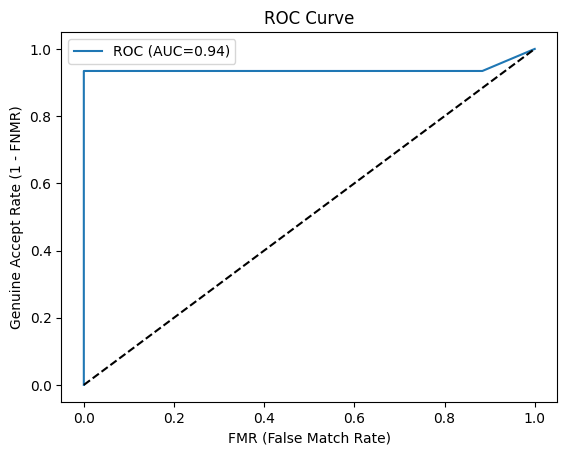

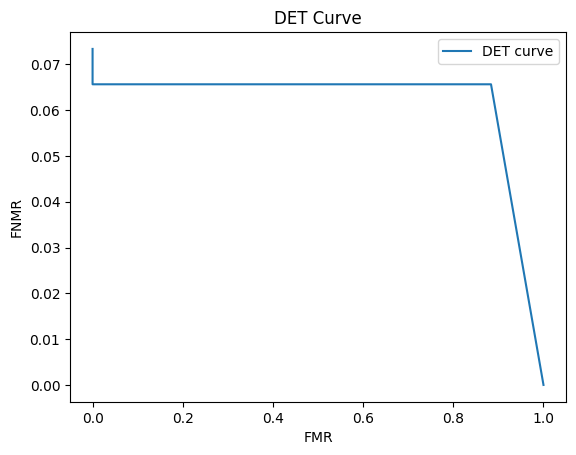

Equal Error Rate (EER): 0.0657 at threshold -72.3333
False Match Rate (FMR) at EER: 0.0657
False Non-Match Rate (FNMR) at EER: 0.0656


In [45]:
import cv2
import numpy as np
from skimage.morphology import skeletonize
from itertools import combinations
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, det_curve, auc

# -----------------------------
# 1. Descriptor Extraction
# -----------------------------
def get_descriptors(img):
    # CLAHE for contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    # Threshold + skeletonization
    _, img_bin = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)
    img_bin = img_bin // 255
    skeleton = skeletonize(img_bin)
    skeleton_img = (skeleton * 255).astype(np.uint8)  # convert back to 0-255 for ORB

    # Harris corners
    harris = cv2.cornerHarris(skeleton_img, 3, 3, 0.04)
    harris_norm = cv2.normalize(harris, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_32FC1)

    keypoints = []
    for x in range(harris_norm.shape[0]):
        for y in range(harris_norm.shape[1]):
            if harris_norm[x, y] > 125:
                keypoints.append(cv2.KeyPoint(y, x, 1))

    orb = cv2.ORB_create()
    _, des = orb.compute(skeleton_img, keypoints)
    return des

# -----------------------------
# 2. Augmentation (example)
# -----------------------------
def augment_v(img, delta=1):
    """Pixel value augmentation: add/subtract a constant value"""
    aug = img.astype(np.int16) + delta   # use int16 to avoid overflow
    aug = np.clip(aug, 0, 255).astype(np.uint8)
    return aug
    import os

def augment(img):
    # identity (no change) for simplicity
    return img

# -----------------------------
# 3. Similarity Score
# -----------------------------
def compute_score(des1, des2):
    if des1 is None or des2 is None or len(des1)==0 or len(des2)==0:
        return -1000  # very low similarity for missing descriptors
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    if len(matches) == 0:
        return -1000
    # Option 1: use negative mean distance
    return -np.mean([m.distance for m in matches])

# -----------------------------
# 4. Evaluate Dataset
# -----------------------------
def evaluate(folder):
    images = [f for f in os.listdir(folder) if f.lower().endswith(".bmp")]
    descriptors = {}

    # Extract descriptors for originals + augmentations
    for img_name in images:
        img = cv2.imread(os.path.join(folder, img_name), cv2.IMREAD_GRAYSCALE)
        des_orig = get_descriptors(img)
        des_aug  = get_descriptors(augment_v(img))
        descriptors[img_name] = (des_orig, des_aug)

    genuine_scores, imposter_scores = [], []

    # Genuine pairs: original vs augmented of SAME image
    for img_name, (des_orig, des_aug) in descriptors.items():
        score = compute_score(des_orig, des_aug)
        genuine_scores.append(score)

    # Imposter pairs: different images
    for (name1, (des1, _)), (name2, (des2, _)) in combinations(descriptors.items(), 2):
        score = compute_score(des1, des2)
        imposter_scores.append(score)

    return genuine_scores, imposter_scores

# -----------------------------
# 5. Metrics & Plots
# -----------------------------
def compute_metrics(genuine_scores, imposter_scores):
    y_true = np.array([1]*len(genuine_scores) + [0]*len(imposter_scores))
    y_scores = np.array(genuine_scores + imposter_scores)

    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr = 1 - tpr

    # Equal Error Rate
    idx_eer = np.nanargmin(np.abs(fpr - fnr))
    eer_threshold = thresholds[idx_eer]
    eer = fpr[idx_eer]

    fmr_at_eer = fpr[idx_eer]
    fnmr_at_eer = fnr[idx_eer]

    # DET curve
    fpr_det, fnr_det, _ = det_curve(y_true, y_scores)

    # Plot ROC
    plt.figure()
    plt.plot(fpr, tpr, label=f"ROC (AUC={auc(fpr, tpr):.2f})")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("FMR (False Match Rate)")
    plt.ylabel("Genuine Accept Rate (1 - FNMR)")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

    # Plot DET
    plt.figure()
    plt.plot(fpr_det, fnr_det, label="DET curve")
    plt.xlabel("FMR")
    plt.ylabel("FNMR")
    plt.title("DET Curve")
    plt.legend()
    plt.show()

    return eer, eer_threshold, fmr_at_eer, fnmr_at_eer

# -----------------------------
# Run evaluation
# -----------------------------
folder = "fd"
genuine_scores, imposter_scores = evaluate(folder)
eer, thr, fmr, fnmr = compute_metrics(genuine_scores, imposter_scores)

print(f"Equal Error Rate (EER): {eer:.4f} at threshold {thr:.4f}")
print(f"False Match Rate (FMR) at EER: {fmr:.4f}")
print(f"False Non-Match Rate (FNMR) at EER: {fnmr:.4f}")
